# 05 — LSTM Deep Learning



## 0. Imports & Setup

In [14]:
import zipfile, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 10,
})
os.makedirs('figures', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print('All imports OK. PyTorch version:', torch.__version__)

All imports OK. PyTorch version: 2.11.0+cpu


## 1. Data Loading — identical to previous notebooks

In [15]:

with zipfile.ZipFile(r'C:/Users/tavis/Downloads/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:/Users/tavis/Downloads/archive (1)')

df = pd.read_csv(
    r'C:/Users/tavis/Downloads/archive (1)/Sample - Superstore.csv',
    encoding='ISO-8859-1'
)
df['Order Date'] = pd.to_datetime(df['Order Date'])


monthly = df.resample('ME', on='Order Date')['Sales'].sum()


split = int(len(monthly) * 0.8)
train = monthly[:split]
test  = monthly[split:]

print(f'Total months : {len(monthly)}')
print(f'Train months : {len(train)}  ({train.index[0].date()} to {train.index[-1].date()})')
print(f'Test  months : {len(test)}   ({test.index[0].date()} to {test.index[-1].date()})')

Total months : 48
Train months : 38  (2014-01-31 to 2017-02-28)
Test  months : 10   (2017-03-31 to 2017-12-31)


## 2. evaluate() Helper + Seed Results from Previous Notebooks

In [16]:
def evaluate(actual, predicted):
    actual    = np.array(actual,    dtype=float).flatten()
    predicted = np.array(predicted, dtype=float).flatten()
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    return {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}


results = {
    'ARIMA': {'RMSE': 25445.61, 'MAE': 19981.86, 'MAPE': 26.46},
    'ETS'  : {'RMSE': 12396.26, 'MAE': 11175.29, 'MAPE': 18.52},
}
print('Results dict seeded with Phase 2 metrics.')

Results dict seeded with Phase 2 metrics.


## 3. Re-run XGBoost to get pred_xgb for the comparison figure

In [17]:
from xgboost import XGBRegressor


df_ml = monthly.reset_index()
df_ml.columns = ['Order Date', 'Sales']
df_ml['lag_1']          = df_ml['Sales'].shift(1)
df_ml['lag_2']          = df_ml['Sales'].shift(2)
df_ml['lag_4']          = df_ml['Sales'].shift(4)
df_ml['lag_12']         = df_ml['Sales'].shift(12)
df_ml['rolling_mean_4'] = df_ml['Sales'].rolling(4).mean()
df_ml['roll_std_4']     = df_ml['Sales'].rolling(4).std()
df_ml['roll_mean_12']   = df_ml['Sales'].rolling(12).mean()
df_ml['month']          = df_ml['Order Date'].dt.month
df_ml['quarter']        = df_ml['Order Date'].dt.quarter
df_ml['week']           = df_ml['Order Date'].dt.isocalendar().week
df_ml['holiday_flag']   = 0
df_ml = df_ml.dropna().copy()

features_xgb = ['lag_1','lag_2','lag_4','lag_12',
                 'rolling_mean_4','roll_std_4','roll_mean_12',
                 'month','quarter','week','holiday_flag']
X_xgb   = df_ml[features_xgb]
y_xgb   = df_ml['Sales']
sp_xgb  = int(len(df_ml) * 0.8)
X_xgb_train, X_xgb_test = X_xgb[:sp_xgb], X_xgb[sp_xgb:]
y_xgb_train, y_xgb_test = y_xgb[:sp_xgb], y_xgb[sp_xgb:]
xgb_test_dates = df_ml['Order Date'].values[sp_xgb:]

model_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
model_xgb.fit(X_xgb_train, y_xgb_train)
pred_xgb = model_xgb.predict(X_xgb_test)

results['XGBoost'] = evaluate(y_xgb_test.values, pred_xgb)
print('XGBoost re-run complete:', results['XGBoost'])

XGBoost re-run complete: {'RMSE': np.float64(16364.5), 'MAE': 13418.58, 'MAPE': np.float64(17.84)}


## 4. Data Preprocessing — Normalise + Create Sequences

In [18]:
SEQ_LEN = 12  

scaler = MinMaxScaler()
scaled = scaler.fit_transform(monthly.values.reshape(-1, 1))

def create_sequences(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y).reshape(-1, 1)

X_all, y_all = create_sequences(scaled, seq_len=SEQ_LEN)

split_lstm = int(len(X_all) * 0.8)
X_train_np, X_test_np = X_all[:split_lstm], X_all[split_lstm:]
y_train_np, y_test_np = y_all[:split_lstm], y_all[split_lstm:]

X_train_t = torch.FloatTensor(X_train_np)
X_test_t  = torch.FloatTensor(X_test_np)
y_train_t = torch.FloatTensor(y_train_np)
y_test_t  = torch.FloatTensor(y_test_np)

y_test_actual  = scaler.inverse_transform(y_test_np).flatten()
test_dates_lstm = monthly.index[SEQ_LEN + split_lstm:]

print(f'Train samples : {X_train_t.shape[0]}')
print(f'Test  samples : {X_test_t.shape[0]}')
print(f'Input shape   : {X_train_t.shape}  (samples, seq_len, features)')

Train samples : 28
Test  samples : 8
Input shape   : torch.Size([28, 12, 1])  (samples, seq_len, features)


## 5. Model Architecture

In [19]:
class DonationLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = DonationLSTM(input_size=1, hidden_size=64, num_layers=2)
print(model)
print(f'\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}')

DonationLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 50,497


## 6. Training Loop + Loss Curve

Epoch   0/100  |  Loss: 0.074089


Epoch  10/100  |  Loss: 0.037540
Epoch  20/100  |  Loss: 0.035794
Epoch  30/100  |  Loss: 0.035832
Epoch  40/100  |  Loss: 0.034483
Epoch  50/100  |  Loss: 0.035013
Epoch  60/100  |  Loss: 0.035414
Epoch  70/100  |  Loss: 0.035581
Epoch  80/100  |  Loss: 0.035029
Epoch  90/100  |  Loss: 0.035460

Training complete.
Approximate convergence epoch: 99


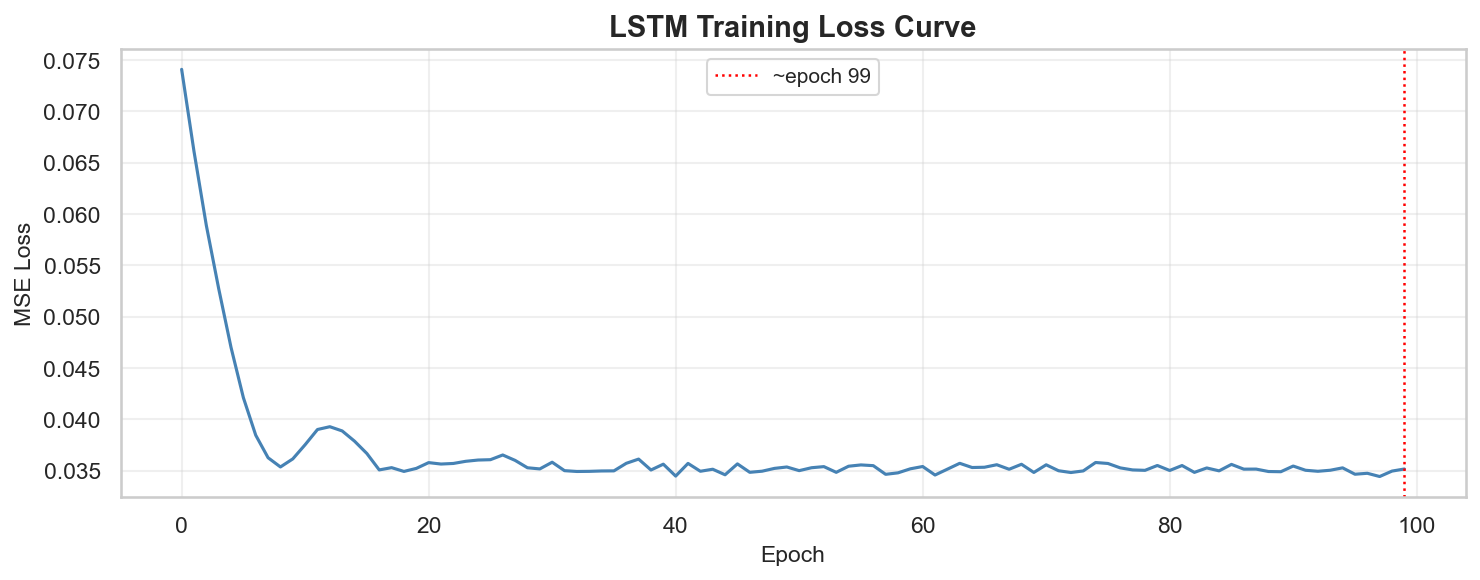

Saved: figures/fig_lstm_loss.png


In [20]:
criterion    = nn.MSELoss()
optimizer    = torch.optim.Adam(model.parameters(), lr=0.001)
NUM_EPOCHS   = 100
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_t)
    loss   = criterion(output, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  |  Loss: {loss.item():.6f}')

print('\nTraining complete.')


conv_epoch = NUM_EPOCHS - 1
for i in range(20, NUM_EPOCHS):
    if abs(train_losses[i] - train_losses[i-10]) < 1e-7:
        conv_epoch = i
        break
print(f'Approximate convergence epoch: {conv_epoch}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color='steelblue', linewidth=1.5)
ax.axvline(conv_epoch, color='red', linestyle=':', linewidth=1.2, label=f'~epoch {conv_epoch}')
ax.set_title('LSTM Training Loss Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_lstm_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_lstm_loss.png')

## 7. Evaluation — Univariate LSTM

=== LSTM Metrics ===
  RMSE: 36231.84
  MAE: 27450.21
  MAPE: 31.46


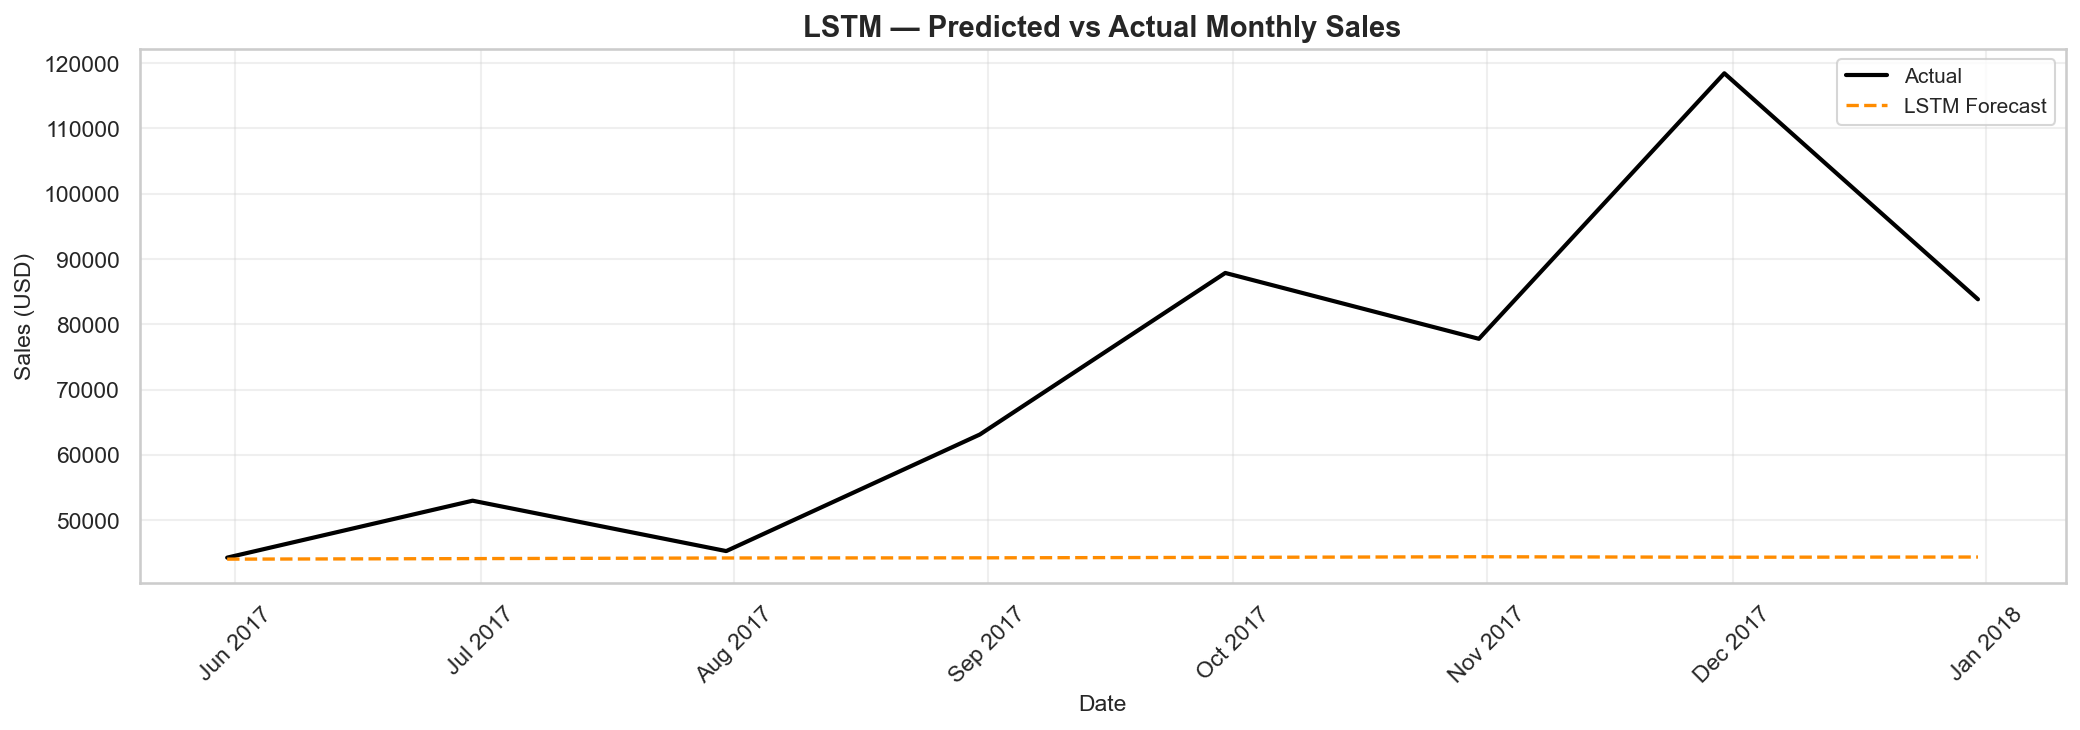

Saved: figures/fig_lstm_forecast.png


In [21]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).numpy()

preds_lstm   = scaler.inverse_transform(preds_scaled).flatten()
lstm_metrics = evaluate(y_test_actual, preds_lstm)
results['LSTM'] = lstm_metrics

print('=== LSTM Metrics ===')
for k, v in lstm_metrics.items():
    print(f'  {k}: {v}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates_lstm, y_test_actual, label='Actual',        color='black',      linewidth=2)
ax.plot(test_dates_lstm, preds_lstm,    label='LSTM Forecast', color='darkorange', linewidth=1.6, linestyle='--')
ax.set_title('LSTM — Predicted vs Actual Monthly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_lstm_forecast.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_lstm_forecast.png')

## 8. Hyperparameter Sensitivity

In [22]:
def train_and_eval_lstm(hidden_size=64, seq_len=12, num_layers=2, epochs=100, lr=0.001):
    X_s, y_s = create_sequences(scaled, seq_len=seq_len)
    sp = int(len(X_s) * 0.8)
    Xtr = torch.FloatTensor(X_s[:sp])
    Xte = torch.FloatTensor(X_s[sp:])
    ytr = torch.FloatTensor(y_s[:sp])
    yte_actual = scaler.inverse_transform(y_s[sp:]).flatten()
    m   = DonationLSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.MSELoss()
    for _ in range(epochs):
        m.train(); opt.zero_grad()
        loss = crit(m(Xtr), ytr)
        loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        p = scaler.inverse_transform(m(Xte).numpy()).flatten()
    return evaluate(yte_actual, p)['MAPE']

print('=== hidden_size sweep ===')
hs_results = {}
for hs in [32, 64, 128]:
    mape = train_and_eval_lstm(hidden_size=hs)
    hs_results[hs] = mape
    print(f'  hidden_size={hs:3d}  MAPE={mape:.2f}%')
best_hs = min(hs_results, key=hs_results.get)

print('\n=== seq_len sweep ===')
sl_results = {}
for sl in [6, 12, 24]:
    mape = train_and_eval_lstm(seq_len=sl)
    sl_results[sl] = mape
    print(f'  seq_len={sl:2d}  MAPE={mape:.2f}%')
best_sl = min(sl_results, key=sl_results.get)

print('\n=== num_layers sweep ===')
nl_results = {}
for nl in [1, 2]:
    mape = train_and_eval_lstm(num_layers=nl)
    nl_results[nl] = mape
    print(f'  num_layers={nl}  MAPE={mape:.2f}%')

print(f'\nBest hidden_size : {best_hs}  (MAPE={hs_results[best_hs]:.2f}%)')
print(f'Best seq_len     : {best_sl}  (MAPE={sl_results[best_sl]:.2f}%)')

=== hidden_size sweep ===
  hidden_size= 32  MAPE=30.91%
  hidden_size= 64  MAPE=31.15%
  hidden_size=128  MAPE=31.19%

=== seq_len sweep ===
  seq_len= 6  MAPE=29.42%
  seq_len=12  MAPE=31.22%
  seq_len=24  MAPE=41.47%

=== num_layers sweep ===
  num_layers=1  MAPE=30.59%
  num_layers=2  MAPE=30.95%

Best hidden_size : 32  (MAPE=30.91%)
Best seq_len     : 6  (MAPE=29.42%)


## 9. Multivariate LSTM (holiday_flag + month)

In [23]:
df_mv = pd.DataFrame({'Sales': monthly.values}, index=monthly.index)
df_mv['month']        = df_mv.index.month
df_mv['holiday_flag'] = 0
# Indian holiday months: Diwali (Oct/Nov), Christmas (Dec)
df_mv.loc[df_mv['month'].isin([10, 11, 12]), 'holiday_flag'] = 1

scaler_mv    = MinMaxScaler()
scaler_sales = MinMaxScaler()
scaled_mv    = scaler_mv.fit_transform(df_mv[['Sales', 'holiday_flag', 'month']].values)
scaler_sales.fit(df_mv[['Sales']].values)

def create_sequences_mv(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len, :])
        y.append(data[i + seq_len, 0])
    return np.array(X), np.array(y).reshape(-1, 1)

X_mv, y_mv = create_sequences_mv(scaled_mv, seq_len=SEQ_LEN)
sp_mv = int(len(X_mv) * 0.8)

X_mv_train_t     = torch.FloatTensor(X_mv[:sp_mv])
X_mv_test_t      = torch.FloatTensor(X_mv[sp_mv:])
y_mv_train_t     = torch.FloatTensor(y_mv[:sp_mv])
y_mv_test_actual = scaler_sales.inverse_transform(y_mv[sp_mv:]).flatten()

model_mv = DonationLSTM(input_size=3, hidden_size=64, num_layers=2)
opt_mv   = torch.optim.Adam(model_mv.parameters(), lr=0.001)
crit_mv  = nn.MSELoss()

for epoch in range(100):
    model_mv.train(); opt_mv.zero_grad()
    loss = crit_mv(model_mv(X_mv_train_t), y_mv_train_t)
    loss.backward(); opt_mv.step()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}  Loss: {loss.item():.6f}')

model_mv.eval()
with torch.no_grad():
    preds_mv = scaler_sales.inverse_transform(model_mv(X_mv_test_t).numpy()).flatten()

mv_metrics = evaluate(y_mv_test_actual, preds_mv)
results['LSTM_multivariate'] = mv_metrics

print('\n=== Multivariate LSTM ===', mv_metrics)
print('=== Univariate  LSTM ===', lstm_metrics)
if mv_metrics['MAPE'] < lstm_metrics['MAPE']:
    print('-> Multivariate IMPROVES upon univariate.')
else:
    print('-> Multivariate does NOT improve upon univariate.')

Epoch 0  Loss: 0.203032
Epoch 20  Loss: 0.039043
Epoch 40  Loss: 0.035557
Epoch 60  Loss: 0.034282
Epoch 80  Loss: 0.031236

=== Multivariate LSTM === {'RMSE': np.float64(28828.3), 'MAE': 22392.0, 'MAPE': np.float64(26.69)}
=== Univariate  LSTM === {'RMSE': np.float64(36231.84), 'MAE': 27450.21, 'MAPE': np.float64(31.46)}
-> Multivariate IMPROVES upon univariate.


## 10. Error Analysis — Top 5 Worst Prediction Months

In [24]:
errors_lstm = np.abs(y_test_actual - preds_lstm)
worst_idx   = np.argsort(errors_lstm)[-5:][::-1]

print('=== Top 5 worst LSTM prediction months ===')
for i in worst_idx:
    print(f'  {test_dates_lstm[i].strftime("%b %Y")}  '
          f'Actual={y_test_actual[i]:,.0f}  '
          f'Pred={preds_lstm[i]:,.0f}  '
          f'AbsError={errors_lstm[i]:,.0f}')

=== Top 5 worst LSTM prediction months ===
  Nov 2017  Actual=118,448  Pred=44,323  AbsError=74,125
  Sep 2017  Actual=87,867  Pred=44,300  AbsError=43,567
  Dec 2017  Actual=83,829  Pred=44,354  AbsError=39,476
  Oct 2017  Actual=77,777  Pred=44,395  AbsError=33,382
  Aug 2017  Actual=63,121  Pred=44,229  AbsError=18,892


## 11. All-Models Comparison Figure (re-fits ARIMA, ETS, Prophet for alignment)

11:10:22 - cmdstanpy - INFO - Chain [1] start processing
11:10:22 - cmdstanpy - INFO - Chain [1] done processing


All baseline models re-fitted.


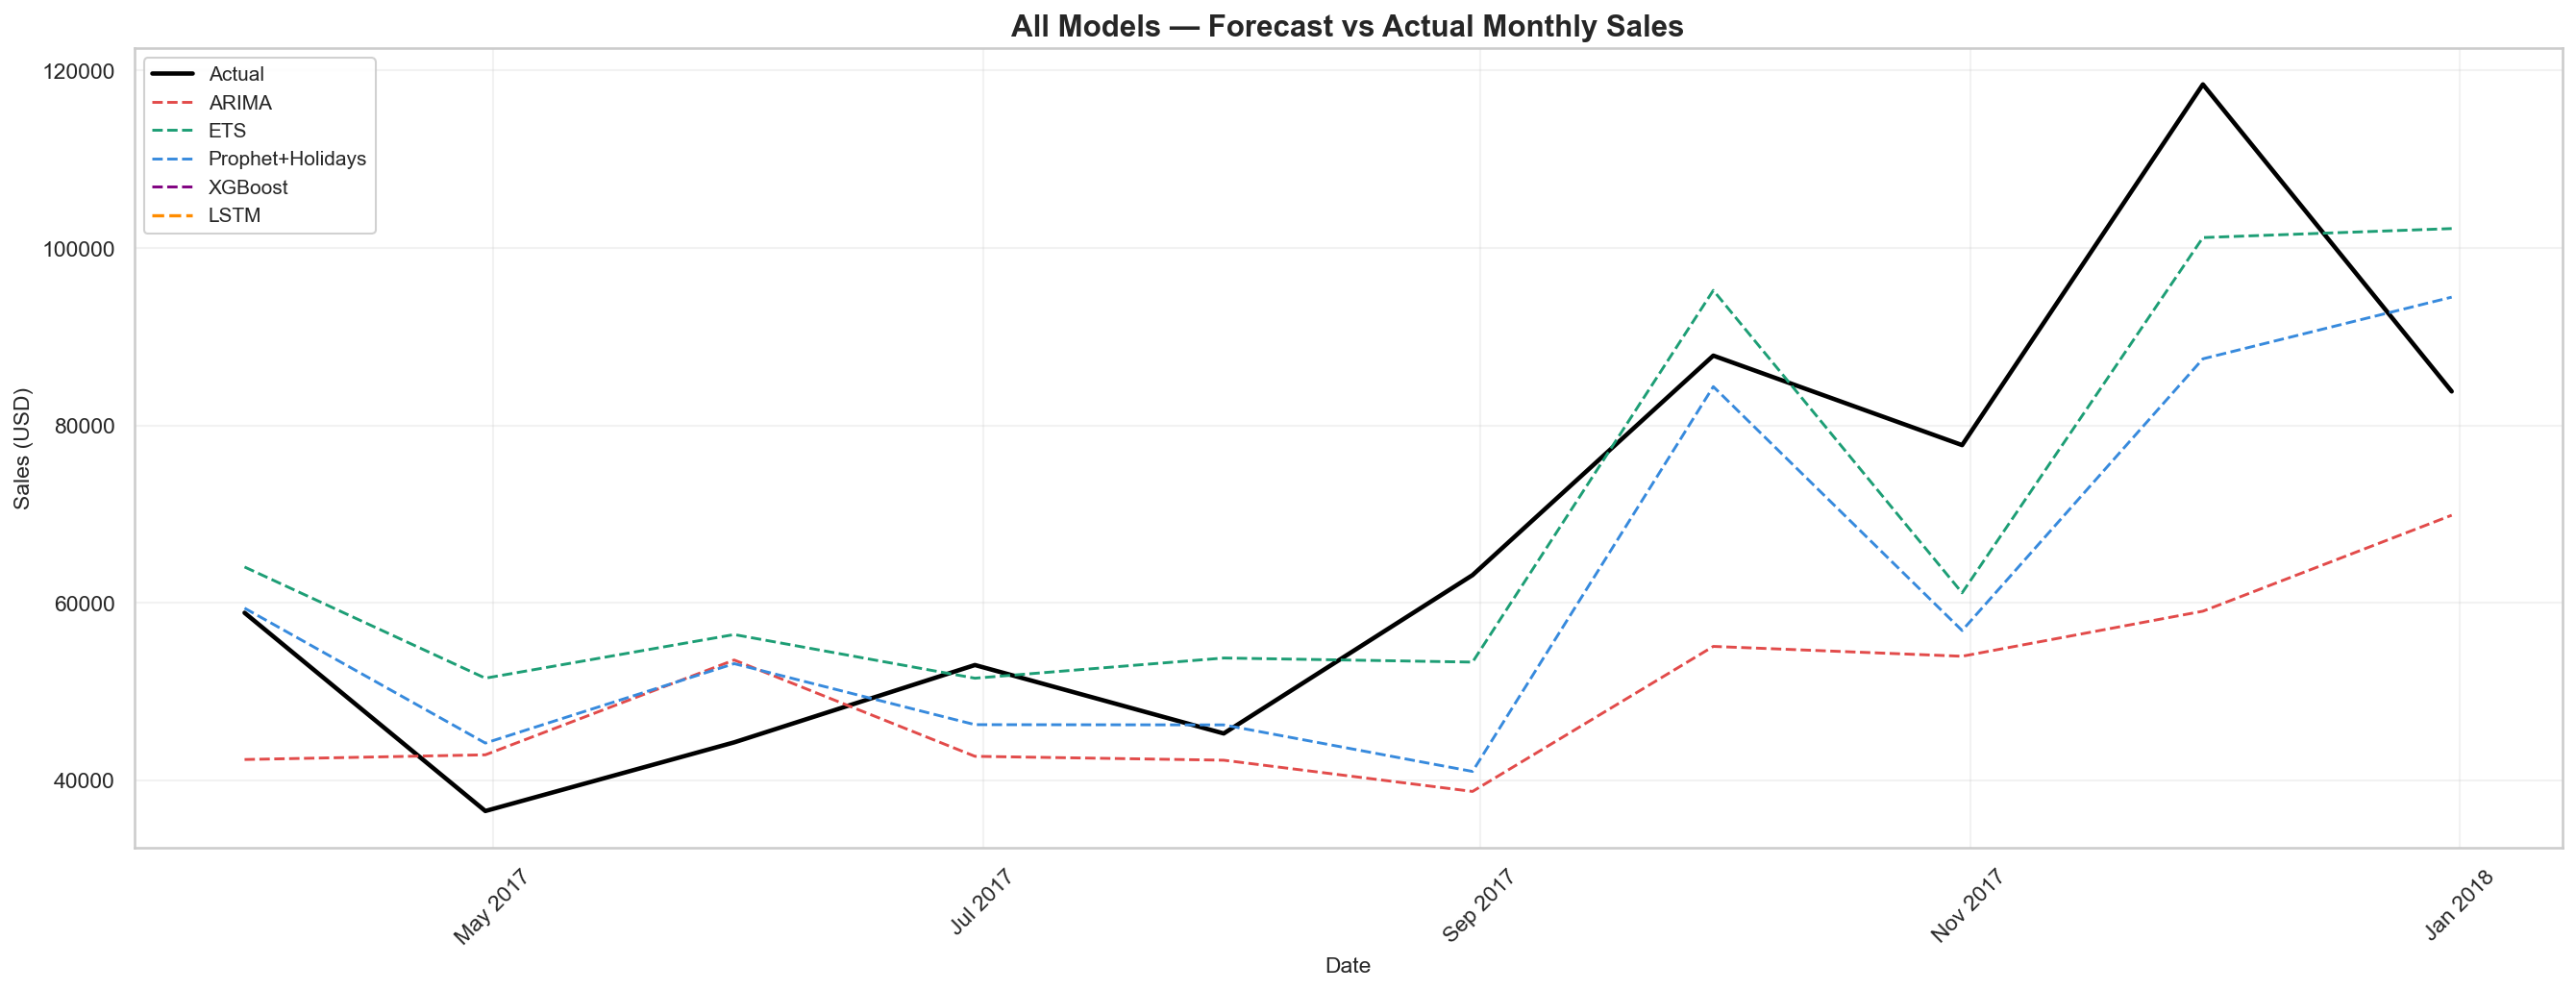

Saved: figures/fig_all_models_compare.png


In [25]:
from pmdarima import auto_arima
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet


model_arima_rf = auto_arima(
    train, seasonal=True, m=12, stepwise=True,
    suppress_warnings=True, information_criterion='aic',
    max_p=3, max_q=3, max_P=2, max_Q=2, D=0, error_action='ignore'
)
forecast_arima_rf = model_arima_rf.predict(n_periods=len(test))

model_ets_rf      = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
forecast_ets_rf   = model_ets_rf.forecast(len(test)).values


df_prophet = monthly.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
train_p = df_prophet.iloc[:split].copy()
test_p  = df_prophet.iloc[split:].copy()
m_h = Prophet(yearly_seasonality=True, weekly_seasonality=False,
               daily_seasonality=False, holidays_prior_scale=10)
m_h.add_country_holidays(country_name='IN')
m_h.fit(train_p)
future_h = m_h.make_future_dataframe(periods=len(test_p), freq='ME')
forecast_h = m_h.predict(future_h)
forecast_prophet_rf = forecast_h[forecast_h['ds'].isin(test_p['ds'])]['yhat'].values
results['Prophet+Holidays'] = evaluate(test_p['y'].values, forecast_prophet_rf)

print('All baseline models re-fitted.')


n_test           = len(test)
common_dates     = test.index
pred_xgb_algn    = pred_xgb[-n_test:]  if len(pred_xgb)   >= n_test else np.full(n_test, np.nan)
pred_lstm_algn   = preds_lstm[-n_test:] if len(preds_lstm) >= n_test else np.full(n_test, np.nan)

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(common_dates, test.values,          label='Actual',           color='black',      linewidth=2.2)
ax.plot(common_dates, forecast_arima_rf,    label='ARIMA',            color='#E24B4A',    linewidth=1.4, linestyle='--')
ax.plot(common_dates, forecast_ets_rf,      label='ETS',              color='#1D9E75',    linewidth=1.4, linestyle='--')
ax.plot(common_dates, forecast_prophet_rf,  label='Prophet+Holidays', color='#378ADD',    linewidth=1.4, linestyle='--')
ax.plot(common_dates, pred_xgb_algn,        label='XGBoost',          color='purple',     linewidth=1.4, linestyle='--')
ax.plot(common_dates, pred_lstm_algn,       label='LSTM',             color='darkorange', linewidth=1.6, linestyle='--')
ax.set_title('All Models — Forecast vs Actual Monthly Sales', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (USD)')
ax.legend(loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('figures/fig_all_models_compare.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figures/fig_all_models_compare.png')

## 12. Save Model + Final Results Table

In [26]:
torch.save(model.state_dict(), 'models/lstm_model.pth')
print('Model saved: models/lstm_model.pth')

results_df = pd.DataFrame(results).T.round(2).sort_values('MAPE')
print('\n=== RESULTS TABLE AFTER NOTEBOOK 05 ===')
print(results_df.to_string())

best_so_far = results_df['MAPE'].idxmin()
print(f'\nBest model so far: {best_so_far}  (MAPE={results_df.loc[best_so_far, "MAPE"]}%)')

Model saved: models/lstm_model.pth

=== RESULTS TABLE AFTER NOTEBOOK 05 ===
                       RMSE       MAE   MAPE
Prophet+Holidays   14811.52  11286.44  16.15
XGBoost            16364.50  13418.58  17.84
ETS                12396.26  11175.29  18.52
ARIMA              25445.61  19981.86  26.46
LSTM_multivariate  28828.30  22392.00  26.69
LSTM               36231.84  27450.21  31.46

Best model so far: Prophet+Holidays  (MAPE=16.15%)
